Nama: Dimas Satria Prayoga

# Import Library

In [ ]:
# ==============================
# 📊 Library Manipulasi Data
# ==============================
import numpy as np  # Library dasar untuk komputasi numerik (array, matriks, dll)
import pandas as pd  # Library untuk analisis dan manipulasi data berbasis tabel (DataFrame)

# ==============================
# 📈 Library Visualisasi
# ==============================
import matplotlib.pyplot as plt  # Untuk membuat visualisasi grafik (plot, chart, dll)
from mpl_toolkits.axes_grid1 import ImageGrid  # Untuk menampilkan beberapa gambar dalam satu grid
import seaborn as sns  # Untuk visualisasi statistik yang lebih menarik dan informatif

# ==============================
# 🖥️ Library Sistem & File
# ==============================
import kagglehub  # Untuk mengakses dan mengunduh dataset dari Kaggle
import os  # Untuk berinteraksi dengan sistem operasi (file, folder, path, dll)
import time  # Untuk mengatur atau menghitung waktu proses
from google.colab import files  # Untuk upload dan download file di Google Colab

# ==============================
# 🤖 Library Machine Learning (Scikit-learn)
# ==============================
from sklearn.model_selection import train_test_split  # Membagi data menjadi train dan test
from sklearn.metrics import accuracy_score  # Menghitung akurasi model klasifikasi
from sklearn.metrics import classification_report  # Menampilkan laporan evaluasi (precision, recall, f1-score)
from sklearn.metrics import confusion_matrix  # Membuat confusion matrix untuk evaluasi model
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.utils import to_categorical

# ==============================
# 🧠 Deep Learning Framework
# ==============================
import tensorflow as tf  # Library utama untuk deep learning dan komputasi numerik
import keras  # API high-level untuk membangun model deep learning (bagian dari TensorFlow)

# ==============================
# 🖼️ Preprocessing Citra
# ==============================
# Untuk membuat generator data gambar dengan augmentasi secara real-time
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Utility tambahan untuk preprocessing gambar
from tensorflow.keras.preprocessing import image
# Untuk memuat gambar ke format PIL (Python Imaging Library)
from tensorflow.keras.preprocessing.image import load_img
# Mengubah gambar (PIL) menjadi array NumPy
from tensorflow.keras.preprocessing.image import img_to_array
# Fungsi preprocessing khusus untuk model EfficientNetV2
from tensorflow.keras.applications.inception_v3 import preprocess_input # Ganti
import cv2 # Library OpenCV untuk pengolahan citra (image processing)
from PIL import Image # Library untuk membuka, memanipulasi, dan menyimpan gambar

# ==============================
# 🏗️ Arsitektur Model (Pretrained CNN)
# ==============================
from tensorflow.keras.applications import InceptionV3 # Ganti
# Model CNN pretrained yang ringan dan efisien
from tensorflow.keras.layers import BatchNormalization
# Layer untuk menstabilkan distribusi data (mean ~0, std ~1)
from tensorflow.keras.layers import Dropout
# Layer untuk mengurangi overfitting dengan mematikan neuron secara acak
from tensorflow.keras.layers import Dense
# Layer fully connected (neural network biasa)
from tensorflow.keras.models import Model
# Untuk membangun model deep learning (menggabungkan layer)
from tensorflow.keras.optimizers import Adamax
# Optimizer (varian Adam) untuk proses training model

# Dataset Retrieval

In [ ]:
# Mengunduh versi terbaru dataset Brain Tumor MRI dari Kaggle menggunakan library kagglehub
path = kagglehub.dataset_download("vibhingupta028/liver-histopathology-fibrosis-ultrasound-images")
# Menentukan path utama folder
parent_dir = os.path.join(path, "Dataset", "Dataset")
print("Path to dataset files:", path)

# Mendefinisikan path spesifik untuk setiap kategori tumor di dalam folder training
no_fibrosis_cases_path = os.path.join(parent_dir, "F0")
portal_fibrosis_cases_path = os.path.join(parent_dir, "F1")
periportal_fibrosis_cases_path = os.path.join(parent_dir, "F2")
septal_fibrosis_cases_path = os.path.join(parent_dir, "F3")
cirrhosis_cases_path = os.path.join(parent_dir, "F4")

# Menampilkan lokasi direktori tiap kelas (untuk verifikasi)
print(f"\nNo Fibrosis cases path set: {no_fibrosis_cases_path}")
print(f"Portal Fibrosis cases path set: {portal_fibrosis_cases_path}")
print(f"Periportal Fibrosis cases path set: {periportal_fibrosis_cases_path}")
print(f"Septal Fibrosis cases path set: {septal_fibrosis_cases_path}")
print(f"Cirrhosis cases path set: {cirrhosis_cases_path} ")

# Menghitung dan menampilkan jumlah file gambar dalam setiap kategori training
print("\nThe number of data items in each path in the training set :")
print(f"No Fibrosis cases: {len(os.listdir(no_fibrosis_cases_path))} images")
print(f"Portal Fibrosis cases: {len(os.listdir(portal_fibrosis_cases_path))} images")
print(f"Periportal Fibrosis cases: {len(os.listdir(periportal_fibrosis_cases_path))} images")
print(f"Septal Fibrosis cases: {len(os.listdir(septal_fibrosis_cases_path))} images")
print(f"Cirrhosis cases: {len(os.listdir(cirrhosis_cases_path))} images")

100%|██████████| 205M/205M [00:01<00:00, 167MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vibhingupta028/liver-histopathology-fibrosis-ultrasound-images/versions/2

No Fibrosis cases path set: /root/.cache/kagglehub/datasets/vibhingupta028/liver-histopathology-fibrosis-ultrasound-images/versions/2/Dataset/Dataset/F0
Portal Fibrosis cases path set: /root/.cache/kagglehub/datasets/vibhingupta028/liver-histopathology-fibrosis-ultrasound-images/versions/2/Dataset/Dataset/F1
Periportal Fibrosis cases path set: /root/.cache/kagglehub/datasets/vibhingupta028/liver-histopathology-fibrosis-ultrasound-images/versions/2/Dataset/Dataset/F2
Septal Fibrosis cases path set: /root/.cache/kagglehub/datasets/vibhingupta028/liver-histopathology-fibrosis-ultrasound-images/versions/2/Dataset/Dataset/F3
Cirrhosis cases path set: /root/.cache/kagglehub/datasets/vibhingupta028/liver-histopathology-fibrosis-ultrasound-images/versions/2/Dataset/Dataset/F4 

The number of data items in each path in the training set :
No Fibrosis cases: 2114 image

# Data Preparation

In [ ]:
# Inisialisasi path dan list
data_dirs = [parent_dir] # Corrected this line to make data_dirs an iterable list
filepaths = []
labels = []

# Loop folder utama (Train & Test)
for data_dir in data_dirs:
  folds = os.listdir(data_dir)

  # Loop setiap kelas
  for fold in folds:
    foldpath = os.path.join(data_dir, fold)
    filelist = os.listdir(foldpath)

    # Loop file gambar
    for file in filelist:
      fpath = os.path.join(foldpath, file)
      filepaths.append(fpath)
      labels.append(fold)

# Konversi ke pandas series
Fseries = pd.Series(filepaths, name='filepaths')
Lseries = pd.Series(labels, name='labels')

# Gabungkan jadi DataFrame
df = pd.concat([Fseries, Lseries], axis=1)

# Ganti labels menjadi nama yang lebih deskriptif
label_mapping = {
    'F0': 'No Fibrosis',
    'F1': 'Portal Fibrosis',
    'F2': 'Periportal Fibrosis',
    'F3': 'Septal Fibrosis',
    'F4': 'Cirrhosis'
}
df['labels'] = df['labels'].replace(label_mapping)

df

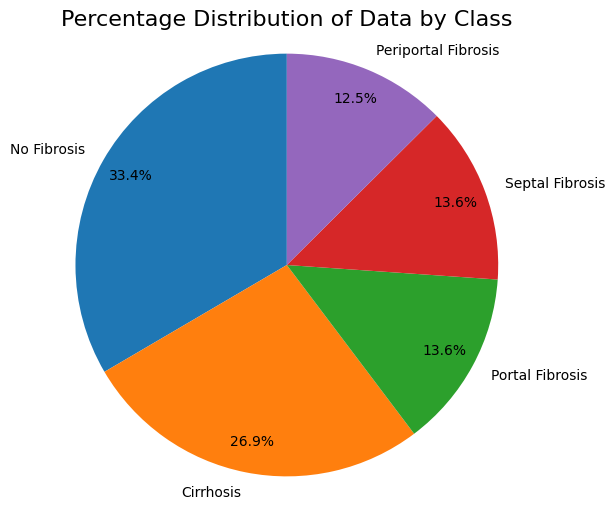

In [ ]:
# Menampilkan distribusi jumlah data tiap kelas dalam bentuk pie chart (diagram lingkaran)
class_counts = df['labels'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
plt.title('Percentage Distribution of Data by Class', fontsize=16)
plt.axis('equal')
plt.show()

# Data Preprocessing

In [ ]:
# Pembagian: 70% Latih, 30% Sisa (untuk Val + Tes)
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['labels'], random_state=42)
# Pembagian Sisa (30%) menjadi dua: 15% Val dan 15% Test
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['labels'], random_state=42)
# Parameter ini memastikan bahwa proporsi kelas sama seperti pada data asli.
print("Train df shape:", train_df.shape)
print("Test df shape:", test_df.shape)
print("Val df shape:", val_df.shape)

Train df shape: (4426, 2)
Test df shape: (949, 2)
Val df shape: (948, 2)


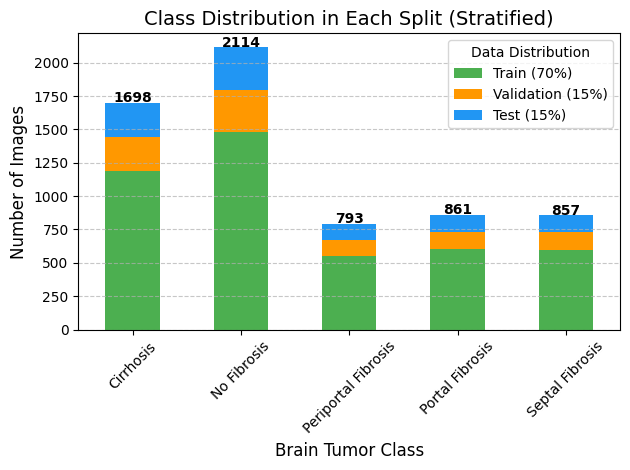

In [ ]:
# Hitung jumlah data per kelas di setiap split
train_counts = train_df['labels'].value_counts().sort_index()
val_counts = val_df['labels'].value_counts().sort_index()
test_counts = test_df['labels'].value_counts().sort_index()

# Siapkan Data untuk Plotting
df_plot = pd.DataFrame({
  "Train (70%)": train_counts,
  "Validation (15%)": val_counts,
  "Test (15%)": test_counts,
})

# Membuat Diagram Batang
ax = df_plot.plot(kind='bar', stacked=True, color=['#4CAF50', '#FF9800', '#2196F3'])
plt.title("Class Distribution in Each Split (Stratified)", fontsize=14)
plt.xlabel("Brain Tumor Class", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.legend(title="Data Distribution")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tambahkan label angka di atas setiap batang
for i, total in enumerate(df_plot.sum(axis=1)):
  ax.text(i, total + 5, int(total), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Menampilkan jumlah data per kelas untuk setiap split (Train, Validation, Test)
df_total = df_plot.copy()
df_total["Total"] = df_plot.sum(axis=1)
display(df_total)

,Train (70%),Validation (15%),Test (15%),Total
labels,,,,
Cirrhosis,1188,255,255,1698
No Fibrosis,1480,317,317,2114
Periportal Fibrosis,555,119,119,793
Portal Fibrosis,603,129,129,861
Septal Fibrosis,600,128,129,857


# Data Generator (Augmentasi & Loading)

In [ ]:
# Hyperparameter yang menentukan jumlah data yang diproses dalam satu iterasi
batch_size = 32
# Ukuran gambar yang akan digunakan (harus sesuai dengan input model)
target_size = (224, 224)

# Membuat generator data untuk training dengan augmentasi (penambahan variasi data)
train_datagen = ImageDataGenerator(
  # Fungsi preprocessing sesuai dengan model yang digunakan
  preprocessing_function=preprocess_input,
  rotation_range=20, # Rotasi gambar secara acak hingga ±20 derajat
  width_shift_range=0.05, # Pergeseran gambar secara horizontal
  height_shift_range=0.05, # Pergeseran gambar secara vertikal
  shear_range=0.05, # Transformasi kemiringan untuk membuat variasi sudut pandang
  zoom_range=0.05, # Zoom in/out secara acak hingga 5%
  horizontal_flip=True, # Membalik gambar secara horizontal secara acak
  fill_mode="nearest" # Mengisi piksel kosong hasil transformasi dengan nilai terdekat
)

# Membuat generator data untuk validasi, hanya preprocessing
val_datagen = ImageDataGenerator(
  preprocessing_function=preprocess_input
)

# Membuat generator data untuk testing, hanya preprocessing
test_datagen = ImageDataGenerator(
  preprocessing_function=preprocess_input
)

# Membuat generator data untuk Training dari dataframe
train_generator = train_datagen.flow_from_dataframe(
  dataframe = train_df, # DataFrame yang berisi path gambar dan label
  x_col = "filepaths", # Kolom yang berisi lokasi file gambar
  y_col = "labels", # Kolom yang berisi label (target/output)
  target_size = target_size, # Mengubah ukuran gambar sesuai input model
  color_mode = 'rgb', # Menggunakan 3 channel warna (RGB)
  class_mode = "categorical", # Digunakan untuk klasifikasi multi-kelas
  batch_size = batch_size, # Jumlah gambar dalam satu batch
  shuffle = True, # Shuffle the data order every epoch
  seed = 42) # Making shuffle results consistent (reproducible)

# Membuat generator data untuk Testing dari dataframe
validation_generator = val_datagen.flow_from_dataframe(
  dataframe = val_df,
  x_col = "filepaths",
  y_col = "labels",
  target_size = target_size,
  color_mode = 'rgb',
  class_mode = "categorical",
  batch_size = batch_size,
  shuffle = False, # Tidak diacak agar evaluasi konsisten dan adil
  seed = 42)

# Membuat generator data untuk Testing dari dataframe
test_generator = test_datagen.flow_from_dataframe(
  dataframe = test_df,
  x_col = "filepaths",
  y_col = "labels",
  target_size = target_size,
  color_mode = 'rgb',
  class_mode = "categorical",
  batch_size = batch_size,
  shuffle = False, # Tidak diacak agar hasil evaluasi sesuai urutan asli
  seed = 42)

Found 4426 validated image filenames belonging to 5 classes.
Found 948 validated image filenames belonging to 5 classes.
Found 949 validated image filenames belonging to 5 classes.


# Exploratory Data Analysis (EDA)

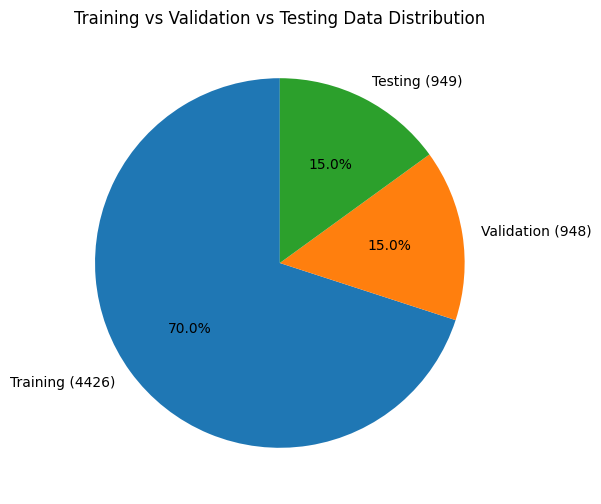

In [ ]:
# Memvisualisasikan proporsi jumlah data pada dataset dalam bentuk pie chart (diagram lingkaran).
counts = [train_generator.samples, validation_generator.samples, test_generator.samples]
labels = [f'Training ({counts[0]})', f'Validation ({counts[1]})', f'Testing ({counts[2]})']
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Training vs Validation vs Testing Data Distribution")
plt.show()

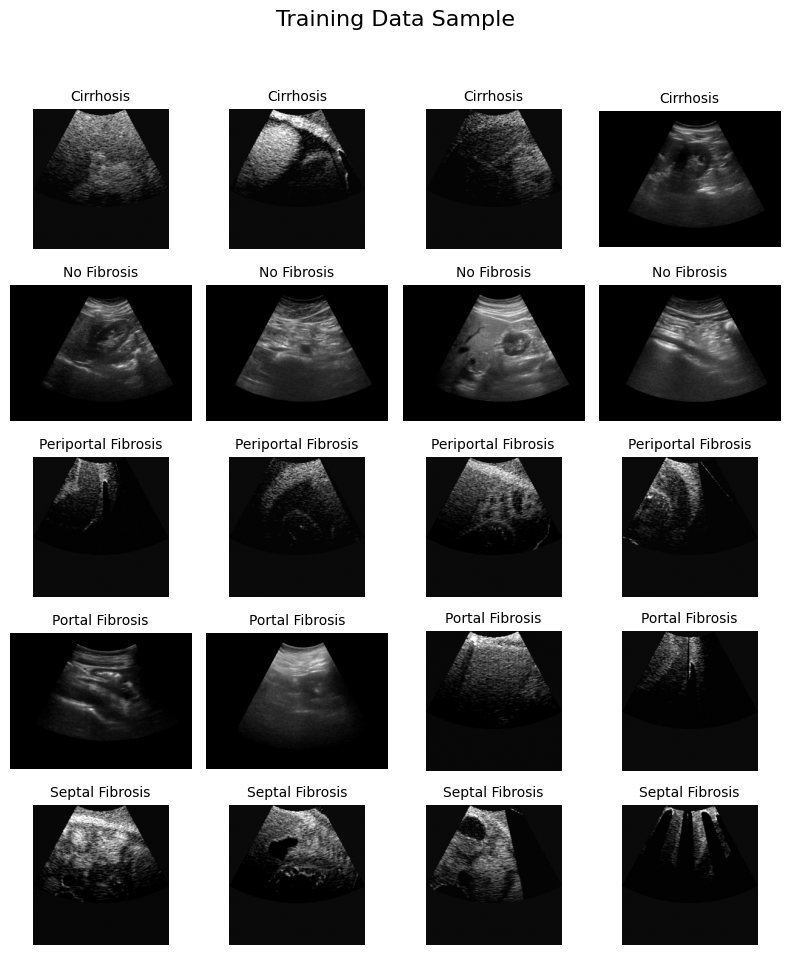

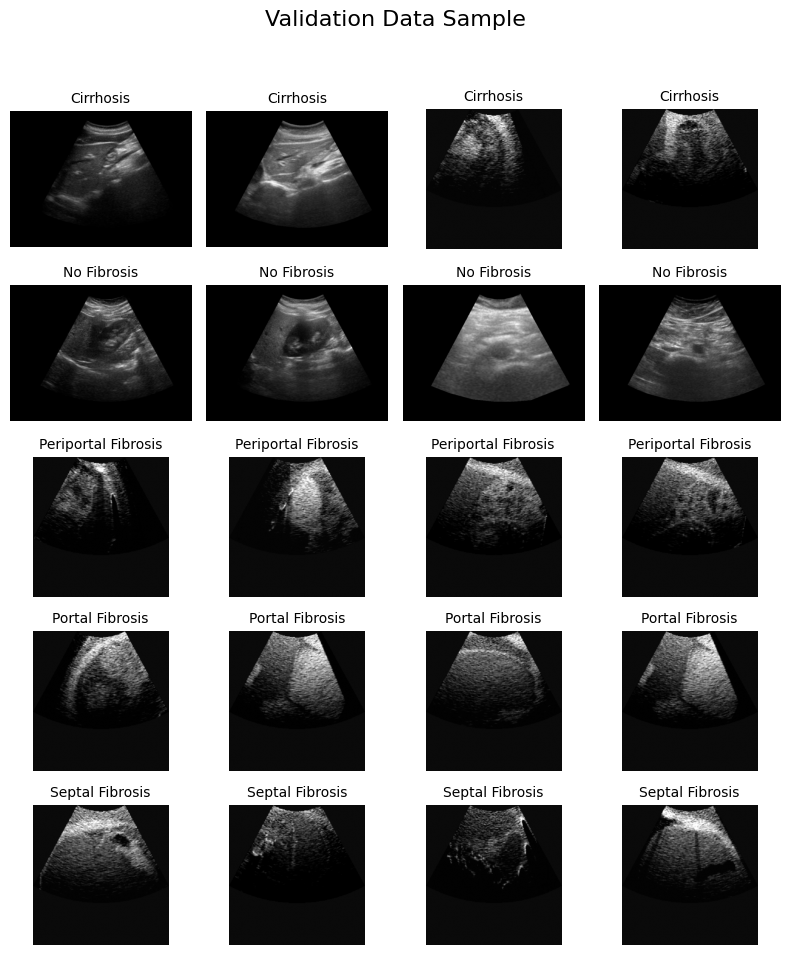

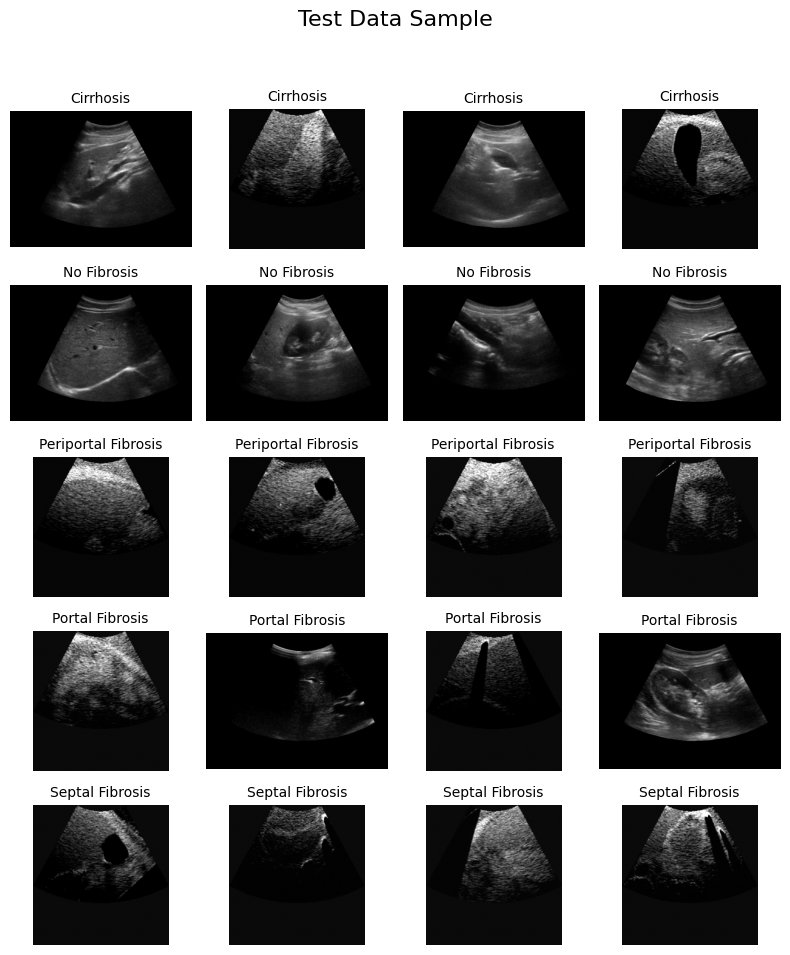

In [ ]:
# Menampilkan beberapa contoh gambar dari setiap kelas (label) pada dataset dalam bentuk grid (tabel gambar)
# Menentukan jumlah gambar per kelas
num_images_per_class = 4

# Mengambil label kelas
class_labels = list(train_generator.class_indices.keys())

# Menyusun dataset yang akan ditampilkan
datasets = [
  (train_df, "Training Data Sample"),
  (val_df, "Validation Data Sample"),
  (test_df, "Test Data Sample")
]

# Loop untuk setiap dataset
for current_df, title in datasets:
  # Membuat canvas gambar
  plt.figure(figsize=(num_images_per_class * 2, len(class_labels) * 2))
  plt.suptitle(title, fontsize=16)

  # Loop tiap kelas
  for i, label in enumerate(class_labels):
    # Ambil filepath berdasarkan kelas
    class_filepaths = current_df[current_df['labels'] == label]['filepaths'].values

    # Random sampling gambar
    if len(class_filepaths) > 0:
      sampled_filepaths = np.random.choice(class_filepaths, min(num_images_per_class, len(class_filepaths)), replace=False)
    else:
      sampled_filepaths = []

    # Menampilkan gambar
    for j, filepath in enumerate(sampled_filepaths):
      # Posisis subplot
      plt.subplot(len(class_labels), num_images_per_class, i * num_images_per_class + j + 1)
      # Membaca gambar dalam grayscale dan menampilkan
      img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE) # Read image as grayscale
      plt.imshow(img, cmap='gray') # Display with 'gray' colormap
      # Tambahkan label
      plt.title(f"{label}", fontsize=10)
      plt.axis('off')

  # Rapikan Layout & Tampilkan hasil
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
  plt.show()


# Model Creation (InceptionV3)

In [ ]:
def build_InceptionV3_model():
  # Instantiates the InceptionV3 architecture.
  base_model = keras.applications.InceptionV3(
    # Model menggunakan layer klasifikasi terakhir (fully connected layer) Xception.
    include_top=False,
    # Model menggunakan bobot yang sudah dilatih pada dataset ImageNet.
    weights='imagenet',
    # Menggunakan input tensor yang sudah dibuat sebelumnya.
    input_tensor=None,
    # Ukuran standar untuk banyak CNN.
    input_shape=(224, 224, 3),
    # 5 Class pada data penyakit Liver
    classes = 5,
    # Softmax digunakan untuk multi-class classification
    classifier_activation='softmax',
  )

  # 🔥 Fine-tuning: freeze sebagian layer
  for layer in base_model.layers[:-30]:
    layer.trainable = False

  # Sisakan layer atas tetap trainable
  for layer in base_model.layers[-30:]:
    layer.trainable = True

  # Menyusun arsitektur model
  model = keras.models.Sequential([
    # Feature extractor dari DenseNet
    base_model,
    # Global average pooling operation untuk 2D data.
    keras.layers.GlobalAveragePooling2D(),
    # Fully connected layer untuk pembelajaran pola penyakit
    keras.layers.Dense(256, activation='relu'),
    # Menstabilkan distribusi aktivasi
    keras.layers.BatchNormalization(),
    # Mengurangi overfitting
    keras.layers.Dropout(0.3),
    # Output layer (5 kelas)
    keras.layers.Dense(5, activation='softmax')
  ])

  return model

# 2. Panggil fungsi untuk membuat model
InceptionV3_model = build_InceptionV3_model()

# 3. Tampilkan ringkasan arsitektur model
InceptionV3_model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,329,637 (85.18 MB)

 Trainable params: 5,682,373 (21.68 MB)

 Non-trainable params: 16,647,264 (63.50 MB)

# Tuning Hyperparameter 1

In [ ]:
# --- Inisialisasi Parameter ---
# Learning rate mengontrol seberapa besar model mengubah bobotnya setiap kali belajar
learning_rate = 0.01
# Epochs adalah jumlah total pengulangan (iterasi) model mempelajari seluruh dataset
epochs = 20

# --- Konfigurasi Optimizer ---
# Menggunakan Adamax, variasi dari optimizer Adam yang lebih stabil untuk model besar
optimizer = Adamax(learning_rate=learning_rate)

# --- Kompilasi Model ---
# Menyiapkan model sebelum dilatih dengan menentukan :
InceptionV3_model.compile(
  optimizer=optimizer,
  loss='categorical_crossentropy',
  metrics=['accuracy'])

# --- Proses Pelatihan (Training) ---
# Melatih model menggunakan data dari train_generator
# Selama proses ini, model juga akan diuji secara berkala menggunakan validation data
# Hasilnya disimpan di variabel 'history' untuk dianalisis grafiknya nanti
history1 = InceptionV3_model.fit(
  train_generator,
  epochs=epochs,
  validation_data=validation_generator)

Epoch 1/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 113s 642ms/step - accuracy: 0.5983 - loss: 1.0182 - val_accuracy: 0.7004 - val_loss: 0.7704
Epoch 2/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 63s 454ms/step - accuracy: 0.7343 - loss: 0.6703 - val_accuracy: 0.7089 - val_loss: 0.7073
Epoch 3/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 62s 446ms/step - accuracy: 0.7747 - loss: 0.5618 - val_accuracy: 0.7732 - val_loss: 0.5626
Epoch 4/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 62s 446ms/step - accuracy: 0.8147 - loss: 0.4729 - val_accuracy: 0.8238 - val_loss: 0.4365
Epoch 5/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 65s 465ms/step - accuracy: 0.8337 - loss: 0.4338 - val_accuracy: 0.8112 - val_loss: 0.5017
Epoch 6/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 63s 450ms/step - accuracy: 0.8640 - loss: 0.3518 - val_accuracy: 0.7827 - val_loss: 0.5723
Epoch 7/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 64s 461ms/step - accuracy: 0.8739 - loss: 0.3434 - val_accuracy: 0.8502 - val_loss: 0.4281
Epoch 8/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 63s 453ms/step - accuracy: 0.8875 - loss: 

# Evaluation Metric 1

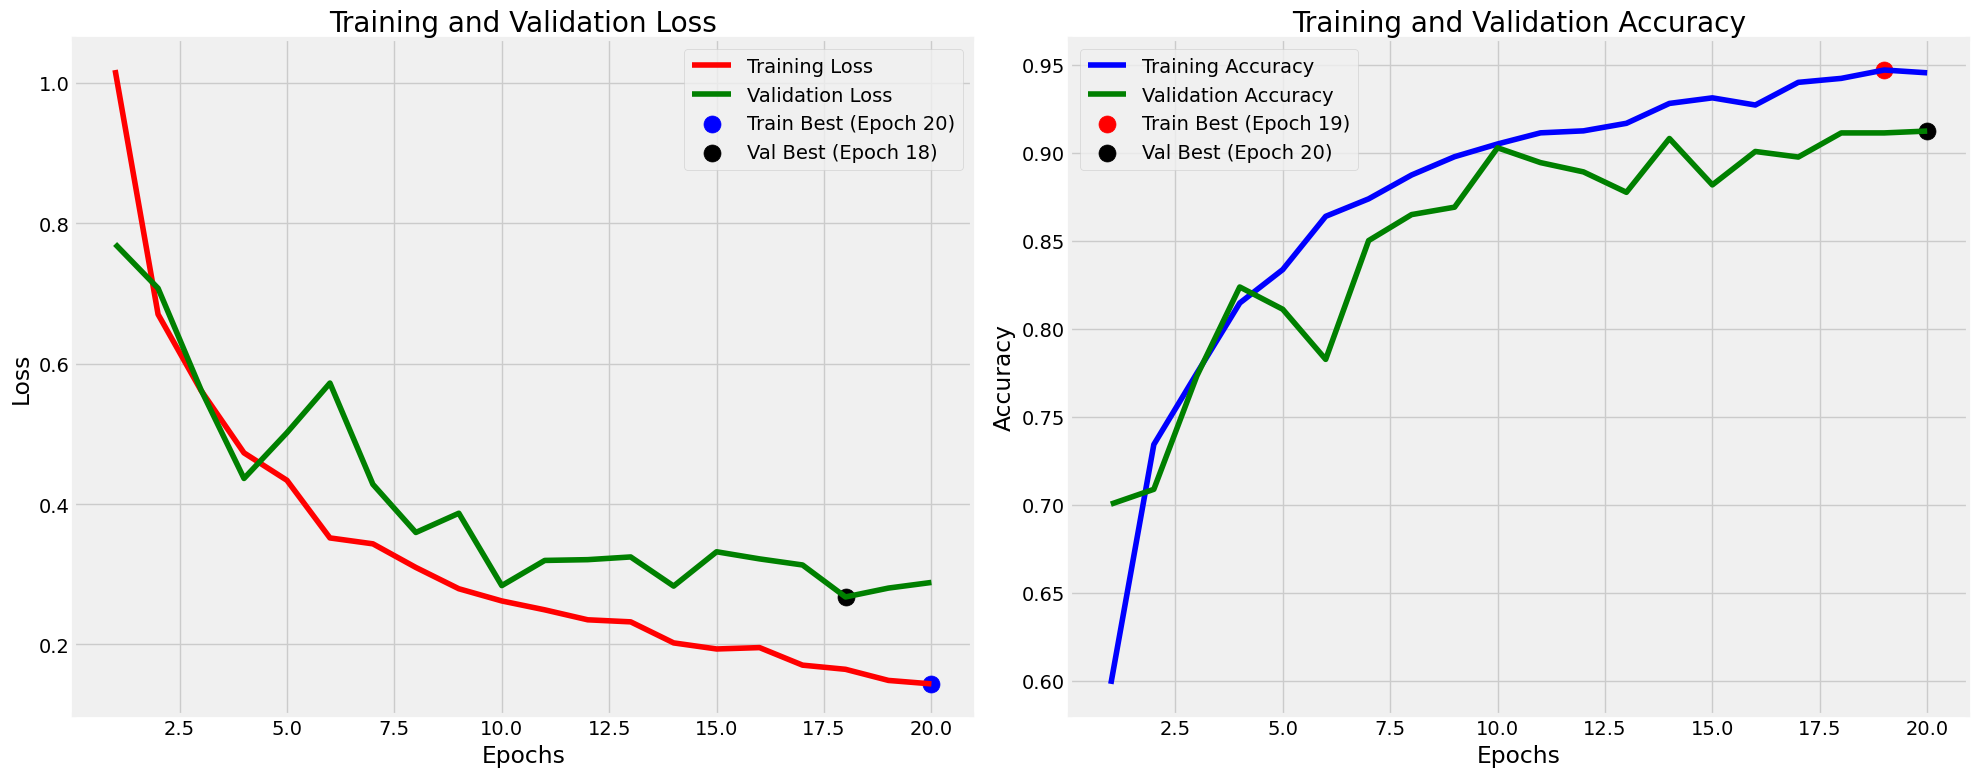

In [ ]:
# Ekstraksi data dari history
train_accuracy = history1.history['accuracy']
train_loss = history1.history['loss']
val_accuracy = history1.history['val_accuracy']
val_loss = history1.history['val_loss']

# Mencari indeks (epoch) di mana loss paling rendah
index_train_loss = np.argmin(train_loss)
train_loss_lowest = train_loss[index_train_loss]
index_val_loss = np.argmin(val_loss)
val_loss_lowest = val_loss[index_val_loss]

# Mencari indeks (epoch) di mana akurasi paling tinggi
index_train_accuracy = np.argmax(train_accuracy)
train_accuracy_highest = train_accuracy[index_train_accuracy]
index_val_accuracy = np.argmax(val_accuracy)
val_accuracy_highest = val_accuracy[index_val_accuracy]

# Persiapan Label dan Sumbu X
Epochs = [i+1 for i in range(len(train_accuracy))]
train_loss_label = f"Train Best (Epoch {index_train_loss+1})"
val_loss_label = f"Val Best (Epoch {index_val_loss+1})"
val_accuracy_label = f"Val Best (Epoch {index_val_accuracy+1})"
train_accuracy_label = f"Train Best (Epoch {index_train_accuracy+1})"

# Visualisasi
plt.figure(figsize=(20, 8))
plt.style.use('fivethirtyeight')

# Visualisasi Loss (Kerugian)
plt.subplot(1, 2, 1)
# Memplot garis Loss untuk data Training (warna merah 'r') dan Validation (warna hijau 'g')
plt.plot(Epochs, train_loss, 'r', label='Training Loss')
plt.plot(Epochs, val_loss, 'g', label='Validation Loss')

# Menandai titik dengan Loss terendah menggunakan scatter plot (titik besar)
plt.scatter(index_train_loss+1, train_loss_lowest, s=150, c='blue', label=train_loss_label)
plt.scatter(index_val_loss+1, val_loss_lowest, s=150, c='black', label=val_loss_label)

# Memberi identitas pada grafik Loss
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Visualisasi Accuracy (Akurasi)
plt.subplot(1, 2, 2)
plt.plot(Epochs, train_accuracy, 'b', label='Training Accuracy') # Added training accuracy plot
plt.plot(Epochs, val_accuracy, 'g', label='Validation Accuracy')

# Menandai titik dengan Akurasi tertinggi menggunakan scatter plot
plt.scatter(index_train_accuracy + 1, train_accuracy_highest, s=150, c='red', label=train_accuracy_label) # Added best train accuracy point
plt.scatter(index_val_accuracy + 1, val_accuracy_highest, s=150, c='black', label=val_accuracy_label)

# Memberi identitas pada grafik Akurasi
plt.title('Training and Validation Accuracy') # Updated title
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Menyesuaikan tata letak agar kedua grafik tidak saling tumpang tindih (rapi)
plt.tight_layout()
plt.show()

In [ ]:
# Mengembalikan pointer atau indeks data testing ke urutan pertama
test_generator.reset()
# Mengambil waktu saat ini (dalam detik) sebelum model mulai bekerja
start_time = time.time()
# Model mengambil data dari test_generator dan memberikan prediksi
Y_pred = InceptionV3_model.predict(test_generator)
# Mencatat waktu tepat setelah model selesai melakukan prediksi terhadap seluruh data
end_time = time.time()
# Menghitung selisih waktu
inference_time = end_time - start_time
# Mengambil indeks dengan nilai tertinggi
y_pred = np.argmax(Y_pred, axis=1)
# Mengambil label asli yang benar dari testing untuk dibandingkan
y_true = test_generator.classes
# Menghitung persentase kecocokan antara jawaban model dan jawaban asli
test_accuracy = accuracy_score(y_true, y_pred)

print(f"Hyperparameter: ")
print(f"Batch Size: {batch_size}")
print(f"Learning Rate: {learning_rate}")
print(f"Epoch: {epochs}")

print(f"\n--- Informasi dari History 1 ---")
print(f"Best Val Acc: {max(val_accuracy):.4f} (Epoch {np.argmax(val_accuracy) + 1})")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Total Prediction Time: {inference_time:.2f} seconds")

30/30 ━━━━━━━━━━━━━━━━━━━━ 23s 421ms/step
Hyperparameter: 
Batch Size: 32
Learning Rate: 0.01
Epoch: 20

--- Informasi dari History 1 ---
Best Val Acc: 0.9124 (Epoch 20)
Testing Accuracy: 0.9220
Total Prediction Time: 23.27 seconds


In [ ]:
# Menampilkan evaluasi performa model klasifikasi secara detail dalam bentuk classification report
print("\n--- Classification Report ---")
class_labels = list(train_generator.class_indices.keys())
cls_report = classification_report(y_true, y_pred, target_names=class_labels, digits=3)
print(cls_report)


--- Classification Report ---
                     precision    recall  f1-score   support

          Cirrhosis      0.946     0.961     0.953       255
        No Fibrosis      1.000     0.972     0.986       317
Periportal Fibrosis      0.769     0.866     0.814       119
    Portal Fibrosis      0.905     0.814     0.857       129
    Septal Fibrosis      0.864     0.884     0.874       129

           accuracy                          0.922       949
          macro avg      0.897     0.899     0.897       949
       weighted avg      0.925     0.922     0.923       949




--- Confusion Matrix ---


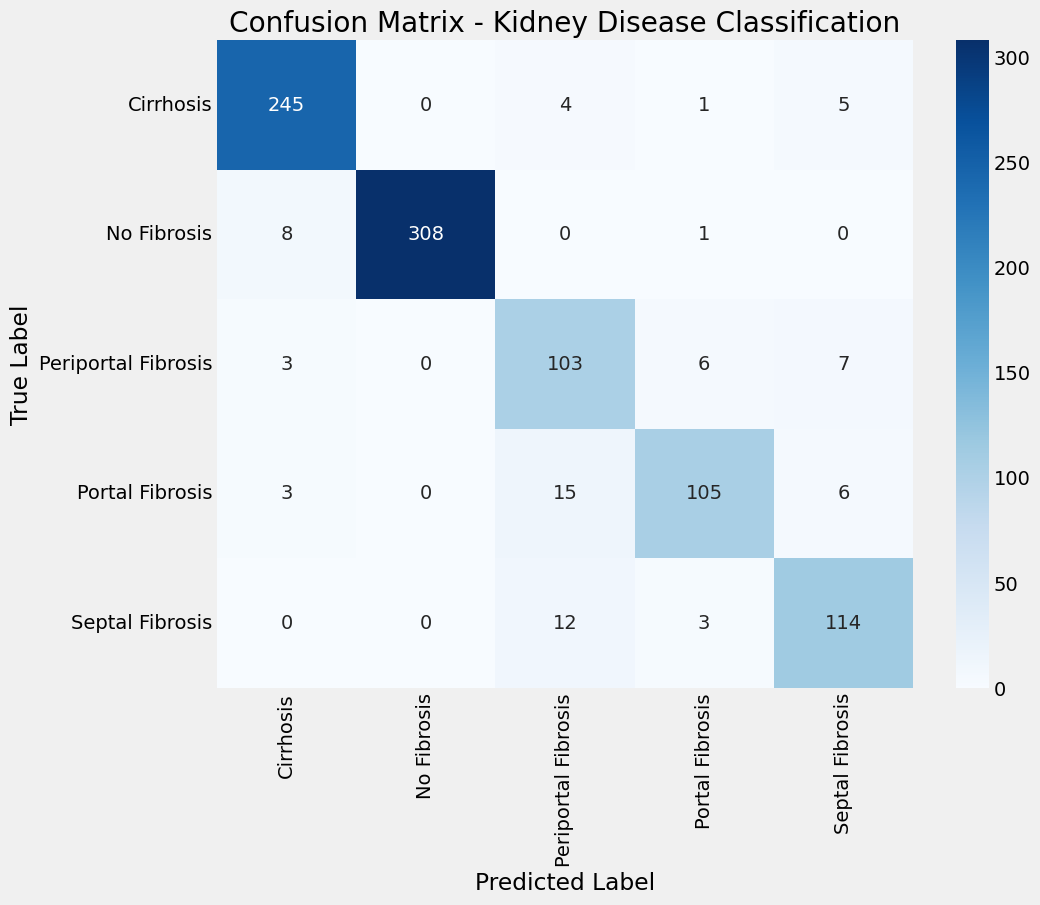

In [ ]:
# Membuat dan menampilkan Confusion Matrix dalam bentuk visual (heatmap)
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix - Kidney Disease Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


--- ROC AUC for History 1 ---


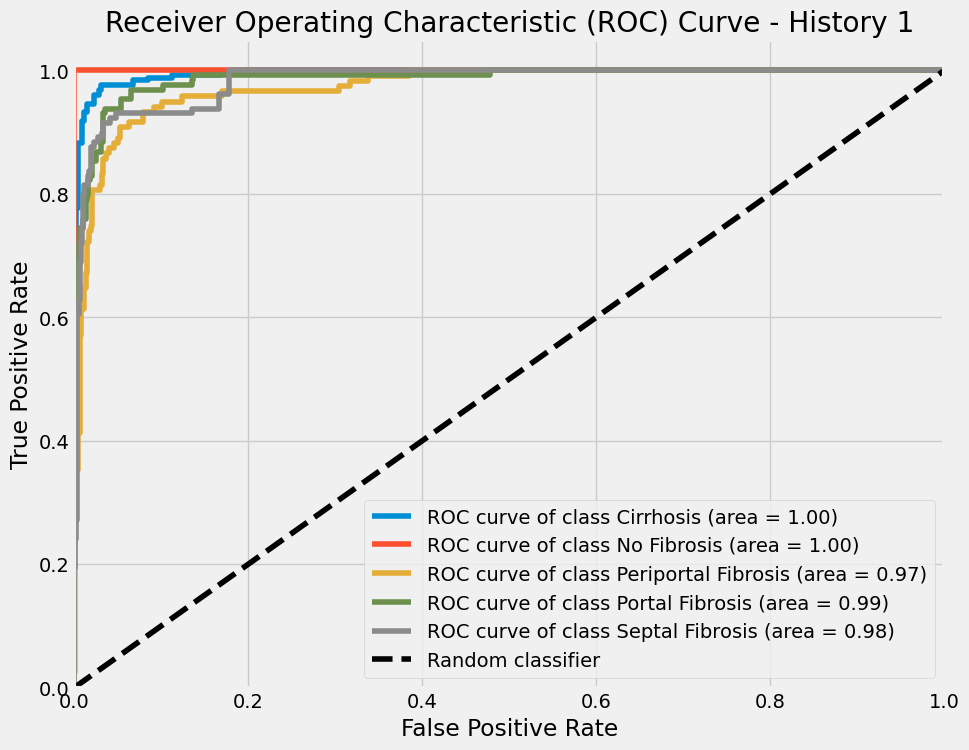

In [ ]:
print("\n--- ROC AUC for History 1 ---")

# One-hot encode y_true for multi-class ROC AUC
y_true_one_hot = to_categorical(y_true, num_classes=len(class_labels))

plt.figure(figsize=(10, 8))
for i in range(len(class_labels)):
    # Get ROC curve for each class
    fpr, tpr, _ = roc_curve(y_true_one_hot[:, i], Y_pred[:, i])
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(fpr, tpr, label=f'ROC curve of class {class_labels[i]} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - History 1')
plt.legend(loc="lower right")
plt.show()

# Tuning Hyperparameter 2

In [ ]:
# Parameter Initialization
learning_rate = 0.005
epochs = 20

# A variant of Adam based on the infinity norm, is a first-order gradient-based optimization method
optimizer = Adamax(learning_rate=learning_rate)
# Configures the model for training.
InceptionV3_model.compile(
  optimizer=optimizer,
  loss='categorical_crossentropy',
  metrics=['accuracy'])

# Trains the model for a fixed number of epochs (dataset iterations).
history2 = InceptionV3_model.fit(
  train_generator,
  epochs=epochs,
  validation_data=validation_generator)

Epoch 1/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 130s 795ms/step - accuracy: 0.9426 - loss: 0.1700 - val_accuracy: 0.9051 - val_loss: 0.2966
Epoch 2/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 72s 520ms/step - accuracy: 0.9634 - loss: 0.1012 - val_accuracy: 0.9325 - val_loss: 0.2109
Epoch 3/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 66s 476ms/step - accuracy: 0.9727 - loss: 0.0742 - val_accuracy: 0.9399 - val_loss: 0.2236
Epoch 4/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 62s 447ms/step - accuracy: 0.9697 - loss: 0.0815 - val_accuracy: 0.9367 - val_loss: 0.2623
Epoch 5/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 94s 677ms/step - accuracy: 0.9740 - loss: 0.0714 - val_accuracy: 0.9420 - val_loss: 0.2112
Epoch 6/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 67s 477ms/step - accuracy: 0.9724 - loss: 0.0802 - val_accuracy: 0.9409 - val_loss: 0.1953
Epoch 7/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 63s 450ms/step - accuracy: 0.9774 - loss: 0.0659 - val_accuracy: 0.9304 - val_loss: 0.2233
Epoch 8/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 64s 457ms/step - accuracy: 0.9763 - loss: 

# Evaluation Metric 2

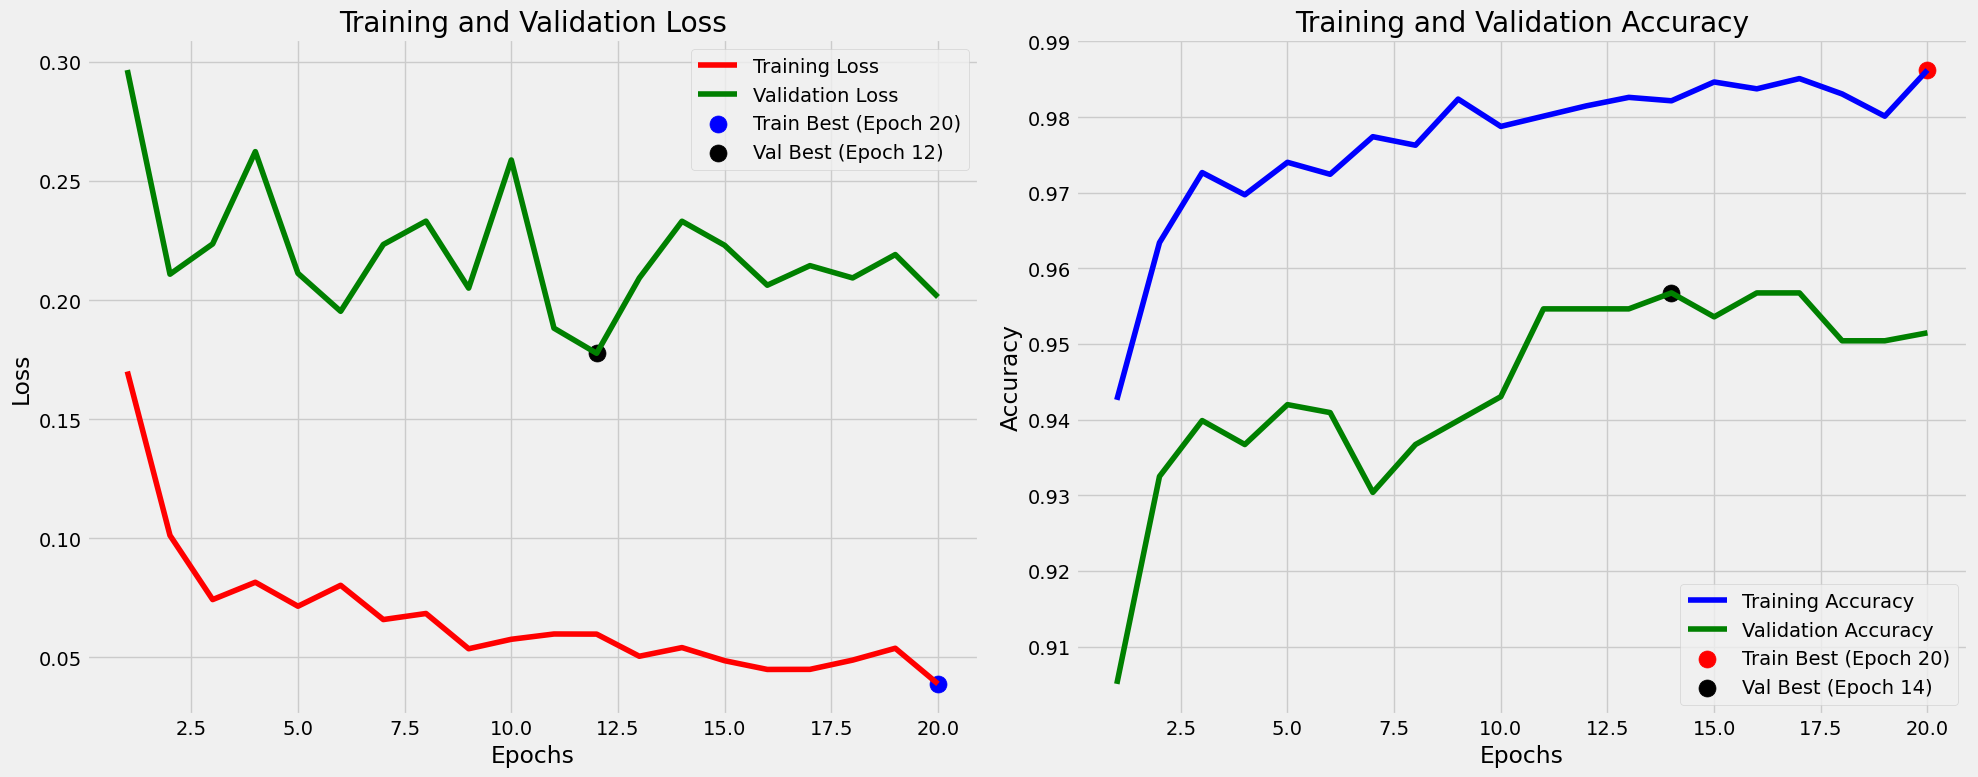

In [ ]:
# Ekstraksi data dari history
train_accuracy = history2.history['accuracy']
train_loss = history2.history['loss']
val_accuracy = history2.history['val_accuracy']
val_loss = history2.history['val_loss']

# Mencari indeks (epoch) di mana loss paling rendah
index_train_loss = np.argmin(train_loss)
train_loss_lowest = train_loss[index_train_loss]
index_val_loss = np.argmin(val_loss)
val_loss_lowest = val_loss[index_val_loss]

# Mencari indeks (epoch) di mana akurasi paling tinggi
index_train_accuracy = np.argmax(train_accuracy)
train_accuracy_highest = train_accuracy[index_train_accuracy]
index_val_accuracy = np.argmax(val_accuracy)
val_accuracy_highest = val_accuracy[index_val_accuracy]

# Preparation of Labels and X Axis
Epochs = [i+1 for i in range(len(train_accuracy))]
train_loss_label = f"Train Best (Epoch {index_train_loss+1})"
val_loss_label = f"Val Best (Epoch {index_val_loss+1})"
val_accuracy_label = f"Val Best (Epoch {index_val_accuracy+1})"
train_accuracy_label = f"Train Best (Epoch {index_train_accuracy+1})"

# Visualization
plt.figure(figsize=(20, 8))
plt.style.use('fivethirtyeight')

# Loss Graph
plt.subplot(1, 2, 1)
plt.plot(Epochs, train_loss, 'r', label='Training Loss')
plt.plot(Epochs, val_loss, 'g', label='Validation Loss')

# The best point on the Loss Graph
plt.scatter(index_train_loss+1, train_loss_lowest, s=150, c='blue', label=train_loss_label)
plt.scatter(index_val_loss+1, val_loss_lowest, s=150, c='black', label=val_loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Graph
plt.subplot(1, 2, 2)
plt.plot(Epochs, train_accuracy, 'b', label='Training Accuracy')
plt.plot(Epochs, val_accuracy, 'g', label='Validation Accuracy')

# The best point on the Accuracy Graph
plt.scatter(index_train_accuracy + 1, train_accuracy_highest, s=150, c='red', label=train_accuracy_label) # Added best train accuracy point
plt.scatter(index_val_accuracy + 1, val_accuracy_highest, s=150, c='black', label=val_accuracy_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Mengembalikan pointer atau indeks data testing ke urutan pertama
test_generator.reset()
# Mengambil waktu saat ini (dalam detik) sebelum model mulai bekerja
start_time = time.time()
# Model mengambil data dari test_generator dan memberikan prediksi
Y_pred = InceptionV3_model.predict(test_generator)
# Mencatat waktu tepat setelah model selesai melakukan prediksi terhadap seluruh data
end_time = time.time()
# Menghitung selisih waktu
inference_time = end_time - start_time
# Mengambil indeks dengan nilai tertinggi
y_pred = np.argmax(Y_pred, axis=1)
# Mengambil label asli yang benar dari testing untuk dibandingkan
y_true = test_generator.classes
# Menghitung persentase kecocokan antara jawaban model dan jawaban asli
test_accuracy = accuracy_score(y_true, y_pred)

print(f"Hyperparameter: ")
print(f"Batch Size: {batch_size}")
print(f"Learning Rate: {learning_rate}")
print(f"Epoch: {epochs}")

print(f"\n--- Informasi dari History 2 ---")
print(f"Best Val Acc: {max(val_accuracy):.4f} (Epoch {np.argmax(val_accuracy) + 1})")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Total Prediction Time: {inference_time:.2f} seconds")

30/30 ━━━━━━━━━━━━━━━━━━━━ 19s 378ms/step
Hyperparameter: 
Batch Size: 32
Learning Rate: 0.005
Epoch: 20

--- Informasi dari History 2 ---
Best Val Acc: 0.9568 (Epoch 14)
Testing Accuracy: 0.9673
Total Prediction Time: 19.38 seconds


In [ ]:
# Menampilkan evaluasi performa model klasifikasi secara detail dalam bentuk classification report
print("\n--- Classification Report ---")
class_labels = list(train_generator.class_indices.keys())
cls_report = classification_report(y_true, y_pred, target_names=class_labels, digits=3)
print(cls_report)


--- Classification Report ---
                     precision    recall  f1-score   support

          Cirrhosis      0.973     0.996     0.984       255
        No Fibrosis      1.000     0.987     0.994       317
Periportal Fibrosis      0.947     0.899     0.922       119
    Portal Fibrosis      0.924     0.946     0.935       129
    Septal Fibrosis      0.938     0.946     0.942       129

           accuracy                          0.967       949
          macro avg      0.957     0.955     0.956       949
       weighted avg      0.967     0.967     0.967       949




--- Confusion Matrix ---


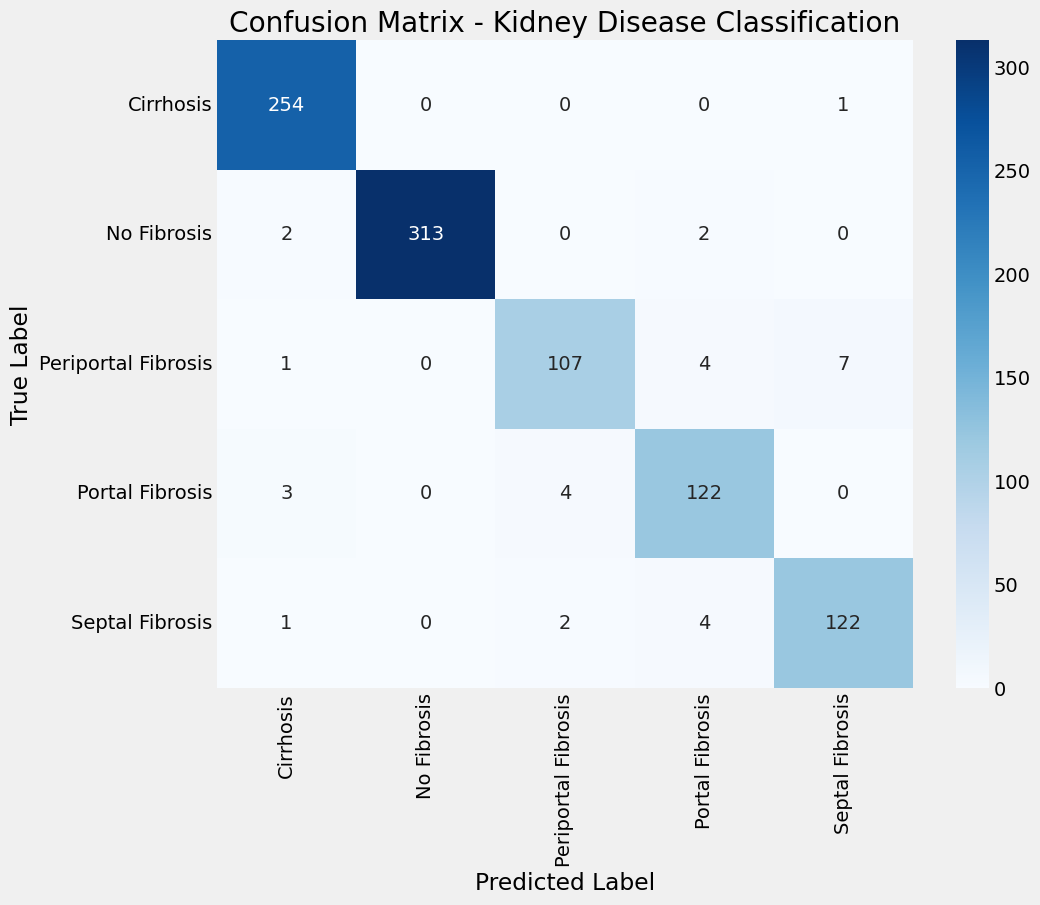

In [ ]:
# Membuat dan menampilkan Confusion Matrix dalam bentuk visual (heatmap)
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix - Kidney Disease Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


--- ROC AUC for History 2 ---


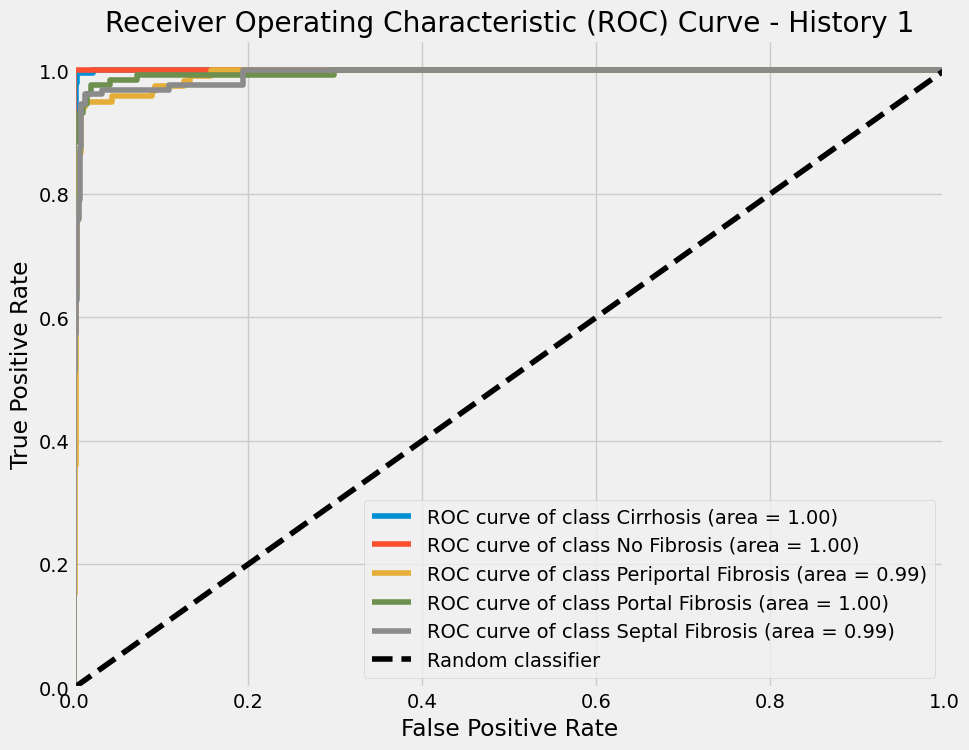

In [ ]:
print("\n--- ROC AUC for History 2 ---")

# One-hot encode y_true for multi-class ROC AUC
y_true_one_hot = to_categorical(y_true, num_classes=len(class_labels))

plt.figure(figsize=(10, 8))
for i in range(len(class_labels)):
    # Get ROC curve for each class
    fpr, tpr, _ = roc_curve(y_true_one_hot[:, i], Y_pred[:, i])
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(fpr, tpr, label=f'ROC curve of class {class_labels[i]} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - History 1')
plt.legend(loc="lower right")
plt.show()

# Tuning Hyperparameter 3

In [ ]:
# Parameter Initialization
learning_rate = 0.001
epochs = 20

# A variant of Adam based on the infinity norm, is a first-order gradient-based optimization method
optimizer = Adamax(learning_rate=learning_rate)
# Configures the model for training.
InceptionV3_model.compile(
  optimizer=optimizer,
  loss='categorical_crossentropy',
  metrics=['accuracy'])

# Trains the model for a fixed number of epochs (dataset iterations).
history3 = InceptionV3_model.fit(
  train_generator,
  epochs=epochs,
  validation_data=validation_generator)

Epoch 1/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 102s 595ms/step - accuracy: 0.9654 - loss: 0.0964 - val_accuracy: 0.9483 - val_loss: 0.1774
Epoch 2/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 62s 442ms/step - accuracy: 0.9727 - loss: 0.0777 - val_accuracy: 0.9388 - val_loss: 0.1882
Epoch 3/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 63s 450ms/step - accuracy: 0.9740 - loss: 0.0733 - val_accuracy: 0.9473 - val_loss: 0.1921
Epoch 4/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 63s 449ms/step - accuracy: 0.9715 - loss: 0.0809 - val_accuracy: 0.9473 - val_loss: 0.1864
Epoch 5/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 62s 448ms/step - accuracy: 0.9781 - loss: 0.0630 - val_accuracy: 0.9451 - val_loss: 0.1792
Epoch 6/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 62s 444ms/step - accuracy: 0.9751 - loss: 0.0748 - val_accuracy: 0.9462 - val_loss: 0.1879
Epoch 7/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 82s 447ms/step - accuracy: 0.9794 - loss: 0.0568 - val_accuracy: 0.9504 - val_loss: 0.1899
Epoch 8/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 62s 449ms/step - accuracy: 0.9794 - loss: 

# Evaluation Metric 3

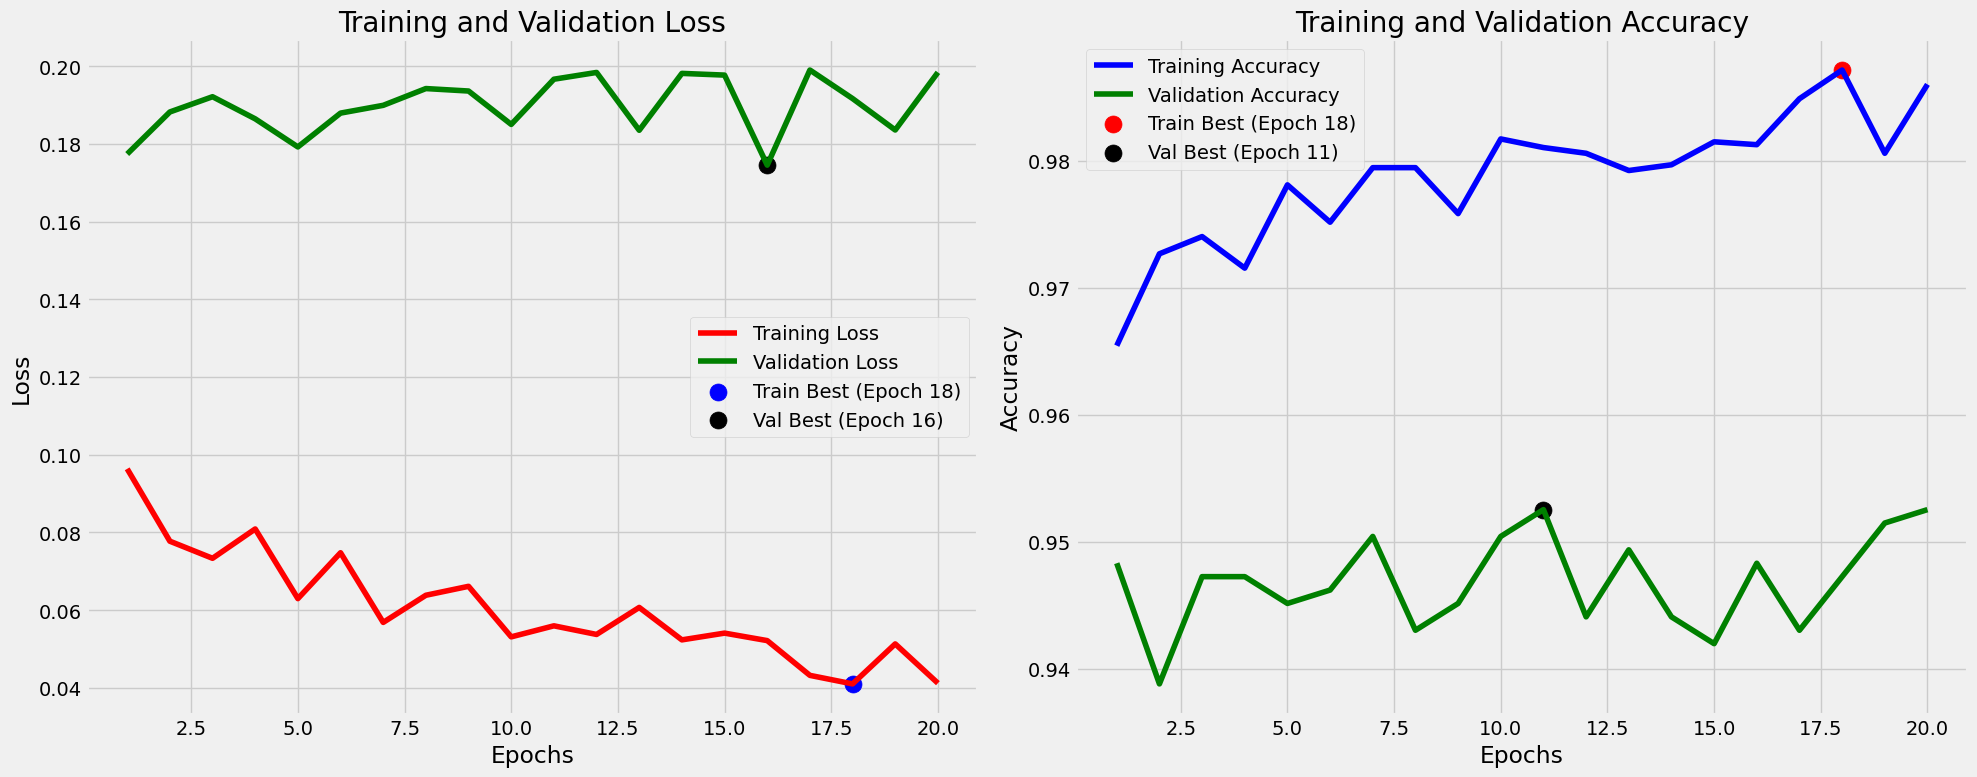

In [ ]:
# Ekstraksi data dari history
train_accuracy = history3.history['accuracy']
train_loss = history3.history['loss']
val_accuracy = history3.history['val_accuracy']
val_loss = history3.history['val_loss']

# Mencari indeks (epoch) di mana loss paling rendah
index_train_loss = np.argmin(train_loss)
train_loss_lowest = train_loss[index_train_loss]
index_val_loss = np.argmin(val_loss)
val_loss_lowest = val_loss[index_val_loss]

# Mencari indeks (epoch) di mana akurasi paling tinggi
index_train_accuracy = np.argmax(train_accuracy)
train_accuracy_highest = train_accuracy[index_train_accuracy]
index_val_accuracy = np.argmax(val_accuracy)
val_accuracy_highest = val_accuracy[index_val_accuracy]

# Preparation of Labels and X Axis
Epochs = [i+1 for i in range(len(train_accuracy))]
train_loss_label = f"Train Best (Epoch {index_train_loss+1})"
val_loss_label = f"Val Best (Epoch {index_val_loss+1})"
val_accuracy_label = f"Val Best (Epoch {index_val_accuracy+1})"
train_accuracy_label = f"Train Best (Epoch {index_train_accuracy+1})"

# Visualization
plt.figure(figsize=(20, 8))
plt.style.use('fivethirtyeight')

# Loss Graph
plt.subplot(1, 2, 1)
plt.plot(Epochs, train_loss, 'r', label='Training Loss')
plt.plot(Epochs, val_loss, 'g', label='Validation Loss')

# The best point on the Loss Graph
plt.scatter(index_train_loss+1, train_loss_lowest, s=150, c='blue', label=train_loss_label)
plt.scatter(index_val_loss+1, val_loss_lowest, s=150, c='black', label=val_loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Graph
plt.subplot(1, 2, 2)
plt.plot(Epochs, train_accuracy, 'b', label='Training Accuracy') # Added training accuracy plot
plt.plot(Epochs, val_accuracy, 'g', label='Validation Accuracy')

# The best point on the Accuracy Graph
plt.scatter(index_train_accuracy + 1, train_accuracy_highest, s=150, c='red', label=train_accuracy_label) # Added best train accuracy point
plt.scatter(index_val_accuracy + 1, val_accuracy_highest, s=150, c='black', label=val_accuracy_label)
plt.title('Training and Validation Accuracy') # Updated title
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Mengembalikan pointer atau indeks data testing ke urutan pertama
test_generator.reset()
# Mengambil waktu saat ini (dalam detik) sebelum model mulai bekerja
start_time = time.time()
# Model mengambil data dari test_generator dan memberikan prediksi
Y_pred = InceptionV3_model.predict(test_generator)
# Mencatat waktu tepat setelah model selesai melakukan prediksi terhadap seluruh data
end_time = time.time()
# Menghitung selisih waktu
inference_time = end_time - start_time
# Mengambil indeks dengan nilai tertinggi
y_pred = np.argmax(Y_pred, axis=1)
# Mengambil label asli yang benar dari testing untuk dibandingkan
y_true = test_generator.classes
# Menghitung persentase kecocokan antara jawaban model dan jawaban asli
test_accuracy = accuracy_score(y_true, y_pred)

print(f"Hyperparameter: ")
print(f"Batch Size: {batch_size}")
print(f"Learning Rate: {learning_rate}")
print(f"Epoch: {epochs}")

print(f"\n--- Informasi dari History 3 ---")
print(f"Best Val Acc: {max(val_accuracy):.4f} (Epoch {np.argmax(val_accuracy) + 1})")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Total Prediction Time: {inference_time:.2f} seconds")

30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step
Hyperparameter: 
Batch Size: 32
Learning Rate: 0.001
Epoch: 20

--- Informasi dari History 3 ---
Best Val Acc: 0.9525 (Epoch 11)
Testing Accuracy: 0.9621
Total Prediction Time: 3.82 seconds


In [ ]:
# Menampilkan evaluasi performa model klasifikasi secara detail dalam bentuk classification report
print("\n--- Classification Report ---")
class_labels = list(train_generator.class_indices.keys())
cls_report = classification_report(y_true, y_pred, target_names=class_labels, digits=3)
print(cls_report)


--- Classification Report ---
                     precision    recall  f1-score   support

          Cirrhosis      0.992     0.996     0.994       255
        No Fibrosis      1.000     1.000     1.000       317
Periportal Fibrosis      0.951     0.824     0.883       119
    Portal Fibrosis      0.887     0.977     0.930       129
    Septal Fibrosis      0.901     0.915     0.908       129

           accuracy                          0.962       949
          macro avg      0.946     0.942     0.943       949
       weighted avg      0.963     0.962     0.962       949




--- Confusion Matrix ---


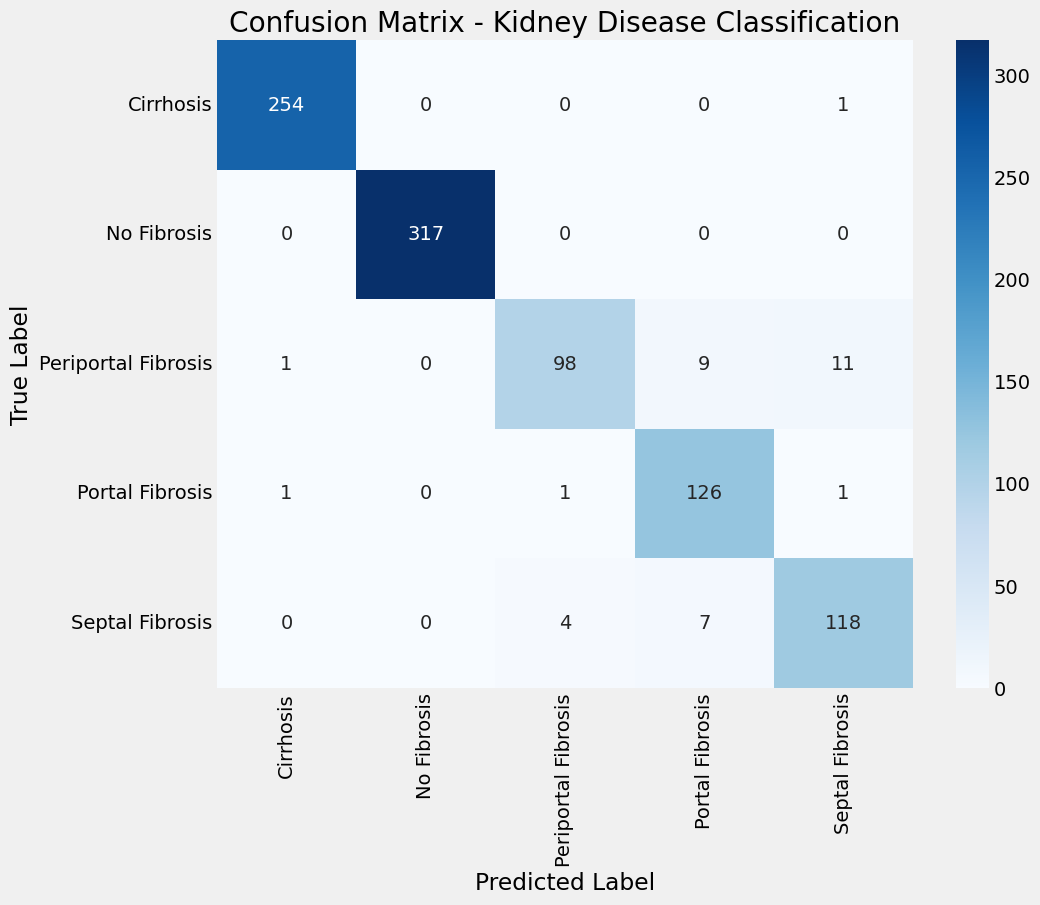

In [ ]:
# Membuat dan menampilkan Confusion Matrix dalam bentuk visual (heatmap)
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix - Kidney Disease Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


--- ROC AUC for History 3 ---


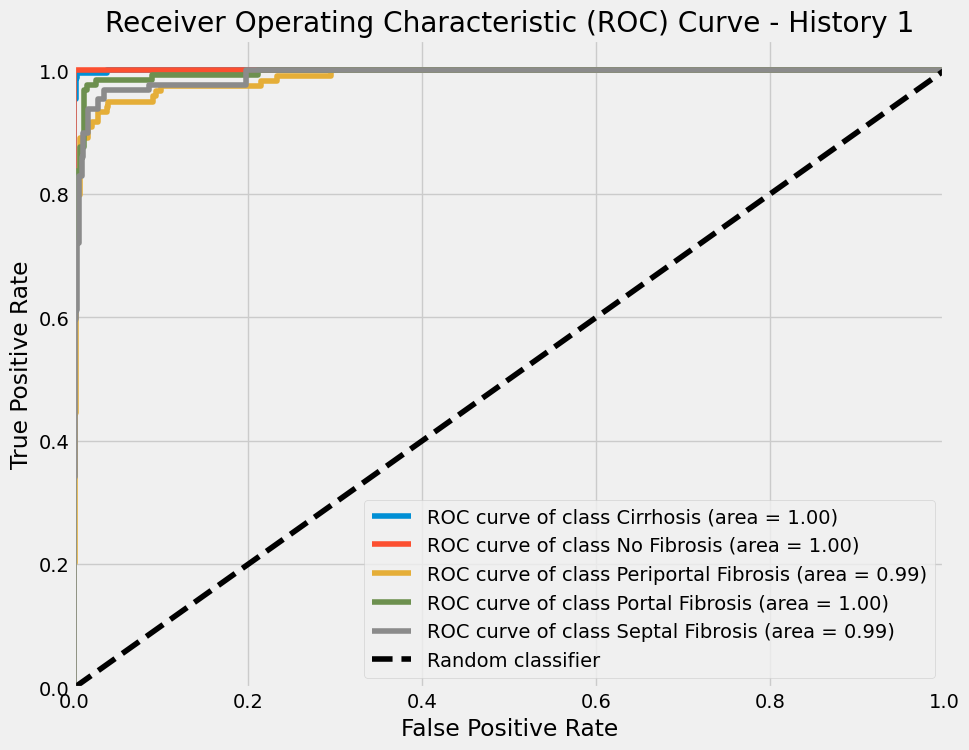

In [ ]:
print("\n--- ROC AUC for History 3 ---")

# One-hot encode y_true for multi-class ROC AUC
y_true_one_hot = to_categorical(y_true, num_classes=len(class_labels))

plt.figure(figsize=(10, 8))
for i in range(len(class_labels)):
    # Get ROC curve for each class
    fpr, tpr, _ = roc_curve(y_true_one_hot[:, i], Y_pred[:, i])
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(fpr, tpr, label=f'ROC curve of class {class_labels[i]} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - History 1')
plt.legend(loc="lower right")
plt.show()

# Prediction on New Image (InceptionV3)

In [ ]:
# --- 1. Persiapan Model ---
InceptionV3_model.save("brain_tumor_classifier_InceptionV3.keras")
# Memuat model yang sudah dilatih dari file .keras
loaded_model = tf.keras.models.load_model("/content/brain_tumor_classifier_InceptionV3.keras", compile=True)
# Mengompilasi ulang model untuk memastikan optimizer dan fungsi loss siap digunakan
loaded_model.compile(Adamax(learning_rate=0.005), loss='categorical_crossentropy', metrics=['accuracy'])

# Fungsi Utama untuk Visualisasi Grad-CAM
def visualize_grad_cam(model, image_path, class_labels):

  image = Image.open(image_path).convert('RGB') # Convert image to RGB

  # --- 2. Preprocessing (Penyesuaian Gambar) ---
  # Mengubah ukuran gambar ke 224x224 (standar MobileNetV3)
  img = image.resize((224, 224))
  img_array = tf.keras.preprocessing.image.img_to_array(img)
  original_img = img_array.copy()
  img_array = tf.expand_dims(img_array, 0)
  preprocessed_img_array = preprocess_input(img_array)

  # --- 3. Inferensi / Prediksi
  # Meminta model menebak gambar
  predictions = model.predict(preprocessed_img_array)
  predicted_class_idx = np.argmax(predictions)
  predicted_class = class_labels[predicted_class_idx]
  confidence = 100 * np.max(predictions)

  # Menampilkan log hasil prediksi di konsol
  print(f"Image path: {image_path}")
  print(f"Predicted class: {predicted_class}")
  print(f"Confidence: {confidence:.2f}%")
  print("\nAll class probabilities:")
  for i, prob in enumerate(predictions[0]):
    print(f"{class_labels[i]}: {100 * prob:.2f}%")

  # --- 4. Persiapan Struktur GRAD-CAM (Pembedahan Model) ---
  # Mengambil 'backbone' model (MobileNetV3Large) yang ada di layer pertama
  base_model_feature_extractor = model.layers[0]
  # Mengambil output dari layer konvolusi terakhir sebagai peta fitur (feature map)
  feature_map_output_tensor = base_model_feature_extractor.output

  # Membuat model sub-bagian untuk mengekstrak fitur visual
  feature_map_model = tf.keras.Model(
    inputs = base_model_feature_extractor.input,
    outputs = feature_map_output_tensor)

  # Menyiapkan input untuk bagian klasifikasi (biasanya berukuran 7x7x960)
  classifier_input_shape = feature_map_output_tensor.shape[1:]
  classifier_input = tf.keras.Input(shape=classifier_input_shape)

  # Menyambungkan kembali lapisan klasifikasi (Dense/Pooling) ke input baru
  x = classifier_input
  for layer in model.layers[1:]:
    x = layer(x)
  classifier_model = tf.keras.Model(inputs=classifier_input, outputs=x)

  # --- 5. Perhitungan Gradien (Mencari Bagian Penting) ---
  # Menggunakan GradientTape untuk merekam operasi matematis demi mendapatkan gradien
  with tf.GradientTape() as tape:
    # 1. Dapatkan peta fitur dari gambar
    feature_map_output = feature_map_model(preprocessed_img_array)
    tape.watch(feature_map_output) # Pantau perubahan pada peta fitur ini

    # 2. Masukkan ke klasifikasi untuk dapat prediksi akhir
    predictions_from_classifier = classifier_model(feature_map_output)
    class_channel = predictions_from_classifier[:, predicted_class_idx]

  # Hitung seberapa sensitif skor prediksi terhadap setiap pixel di peta fitur
  grads = tape.gradient(class_channel, feature_map_output)
  # Ambil rata-rata gradien (Global Average Pooling) untuk menentukan bobot tiap channel
  pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

  # --- 6. Pembuatan Heatmap (Peta Panas) ---
  # Kalikan peta fitur dengan bobot gradien untuk melihat area mana yang paling "berpengaruh"
  last_conv_layer_output_for_heatmap = feature_map_output[0]
  heatmap = last_conv_layer_output_for_heatmap @ pooled_grads[..., tf.newaxis]
  heatmap = tf.squeeze(heatmap) # Hilangkan dimensi yang tidak perlu

  # Normalisasi: Ubah nilai heatmap agar berada di rentang 0 sampai 1 (ReLu + Max)
  heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
  heatmap = heatmap.numpy()

  # --- 7. VISUALISASI AKHIR (Pengaggabungan)
  # Resize heatmap agar ukurannya sama dengan gambar asli (224 x 224)
  original_img_uint8 = np.uint8(original_img)
  heatmap = cv2.resize(heatmap, (original_img_uint8.shape[1], original_img_uint8.shape[0]))
  heatmap = np.uint8(255 * heatmap)
  # Beri warna pada heatmap (Biru = Dingin/Biasa, Merah = Panas/Penting)
  heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET) # Ubah ke skala 0-255

  # Timpa heatmap ke gambar asli dengan transparansi (40% heatmap)
  superimposed_img = heatmap * 0.4 + original_img_uint8
  superimposed_img = np.uint8(255 * (superimposed_img / np.max(superimposed_img)))

  # Tampilkan hasil secara berdampingan: Gambar Asli vs Lokasi Deteksi AI
  plt.figure(figsize=(12, 6))
  plt.subplot(1, 2, 1)
  plt.imshow(img);
  plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
  plt.axis('off')

  plt.subplot(1, 2, 2)
  plt.imshow(superimposed_img)
  plt.title(f"Grad-CAM for {predicted_class}")
  plt.axis('off')

  plt.tight_layout()
  plt.show()

  return predicted_class, confidence, superimposed_img

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Image path: /root/.cache/kagglehub/datasets/vibhingupta028/liver-histopathology-fibrosis-ultrasound-images/versions/2/Dataset/Dataset/F2/I2079.jpg
Predicted class: F2
Confidence: 100.00%

All class probabilities:
F0: 0.00%
F1: 0.00%
F2: 100.00%
F3: 0.00%
F4: 0.00%


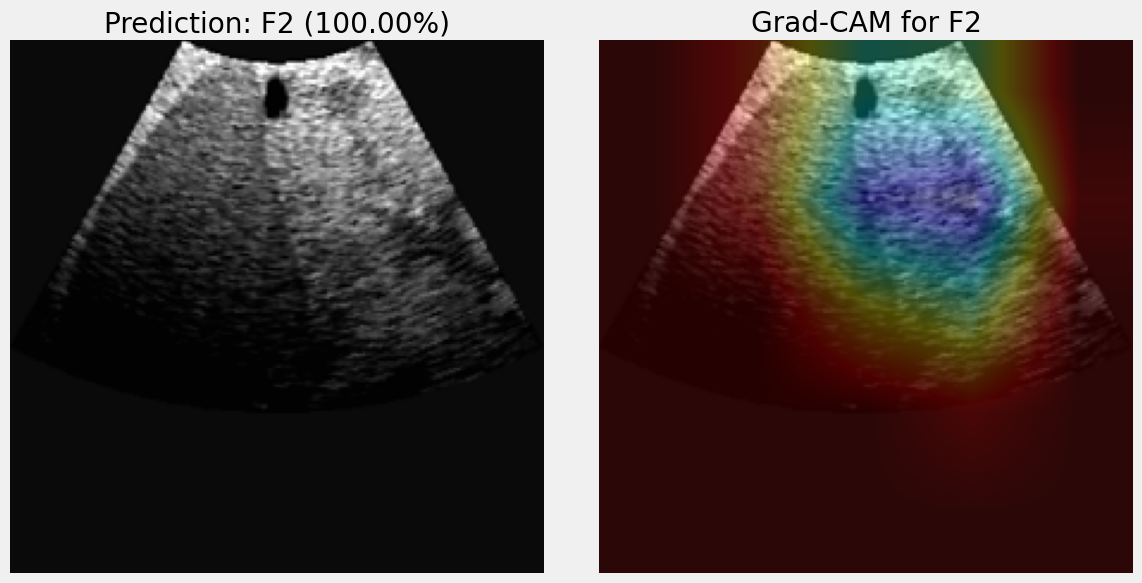

In [ ]:
# Define the image path and class labels
image_path_for_test = os.path.join(parent_dir, "F2", "I2079.jpg")
class_labels_for_test = ['F0', 'F1', 'F2', 'F3', 'F4']
# Call the function
predicted_class, confidence, grad_cam_image = visualize_grad_cam(loaded_model, image_path_for_test, class_labels_for_test)